<!-- # SONAR CLASSIFICATION - PARTIE 1
# Etape 1 : définir le problème à résoudre
# Classifier les signaux sonar: distinguer une mine (M) d'un rocher (R) -->

In [27]:
# Etape 2: Acquérir les données
import numpy as np
import pandas as pd

# Charger les données Sonar
donnees_sonar = pd.read_csv("sonar.all-data.csv", header=None)

# Affichage de la forme des données
print("Forme des données:", donnees_sonar.shape)
print("\nPremières lignes:")
print(donnees_sonar.head())

Forme des données: (208, 61)

Premières lignes:
       0       1       2       3       4       5       6       7       8   \
0  0.0200  0.0371  0.0428  0.0207  0.0954  0.0986  0.1539  0.1601  0.3109   
1  0.0453  0.0523  0.0843  0.0689  0.1183  0.2583  0.2156  0.3481  0.3337   
2  0.0262  0.0582  0.1099  0.1083  0.0974  0.2280  0.2431  0.3771  0.5598   
3  0.0100  0.0171  0.0623  0.0205  0.0205  0.0368  0.1098  0.1276  0.0598   
4  0.0762  0.0666  0.0481  0.0394  0.0590  0.0649  0.1209  0.2467  0.3564   

       9   ...      51      52      53      54      55      56      57  \
0  0.2111  ...  0.0027  0.0065  0.0159  0.0072  0.0167  0.0180  0.0084   
1  0.2872  ...  0.0084  0.0089  0.0048  0.0094  0.0191  0.0140  0.0049   
2  0.6194  ...  0.0232  0.0166  0.0095  0.0180  0.0244  0.0316  0.0164   
3  0.1264  ...  0.0121  0.0036  0.0150  0.0085  0.0073  0.0050  0.0044   
4  0.4459  ...  0.0031  0.0054  0.0105  0.0110  0.0015  0.0072  0.0048   

       58      59  60  
0  0.0090  0.0032   

In [28]:
# Etape 3: préparation des données
import numpy as np
import pandas as pd

# Chargement des données
donnees_sonar = pd.read_csv("sonar.all-data.csv", header=None)

# Nommer les colonnes
# Les 60 premières colonnes sont les features (énergie par bande de fréquence)
# La dernière colonne est le label (M = mine, R = rocher)
colonnes = [f'freq_{i}' for i in range(60)] + ['label']
donnees_sonar.columns = colonnes

print("Colonnes:", donnees_sonar.columns.tolist()[-5:])
print("\nInformations sur le dataset:")
print(donnees_sonar.info())

# Statistiques descriptives
print("\nStatistiques:")
print(donnees_sonar.describe())

# Distribution des labels
print("\nDistribution des labels:")
print(donnees_sonar['label'].value_counts())

# Vérifier les valeurs manquantes
print("\nValeurs manquantes:")
print(donnees_sonar.isnull().sum().sum())

Colonnes: ['freq_56', 'freq_57', 'freq_58', 'freq_59', 'label']

Informations sur le dataset:
<class 'pandas.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 61 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   freq_0   208 non-null    float64
 1   freq_1   208 non-null    float64
 2   freq_2   208 non-null    float64
 3   freq_3   208 non-null    float64
 4   freq_4   208 non-null    float64
 5   freq_5   208 non-null    float64
 6   freq_6   208 non-null    float64
 7   freq_7   208 non-null    float64
 8   freq_8   208 non-null    float64
 9   freq_9   208 non-null    float64
 10  freq_10  208 non-null    float64
 11  freq_11  208 non-null    float64
 12  freq_12  208 non-null    float64
 13  freq_13  208 non-null    float64
 14  freq_14  208 non-null    float64
 15  freq_15  208 non-null    float64
 16  freq_16  208 non-null    float64
 17  freq_17  208 non-null    float64
 18  freq_18  208 non-null    float64
 19  freq_19  

Moyenne des 5 premières features par classe:
         freq_0    freq_1    freq_2    freq_3    freq_4
label                                                  
M      0.034989  0.045544  0.050720  0.064768  0.086715
R      0.022498  0.030303  0.035951  0.041447  0.062028


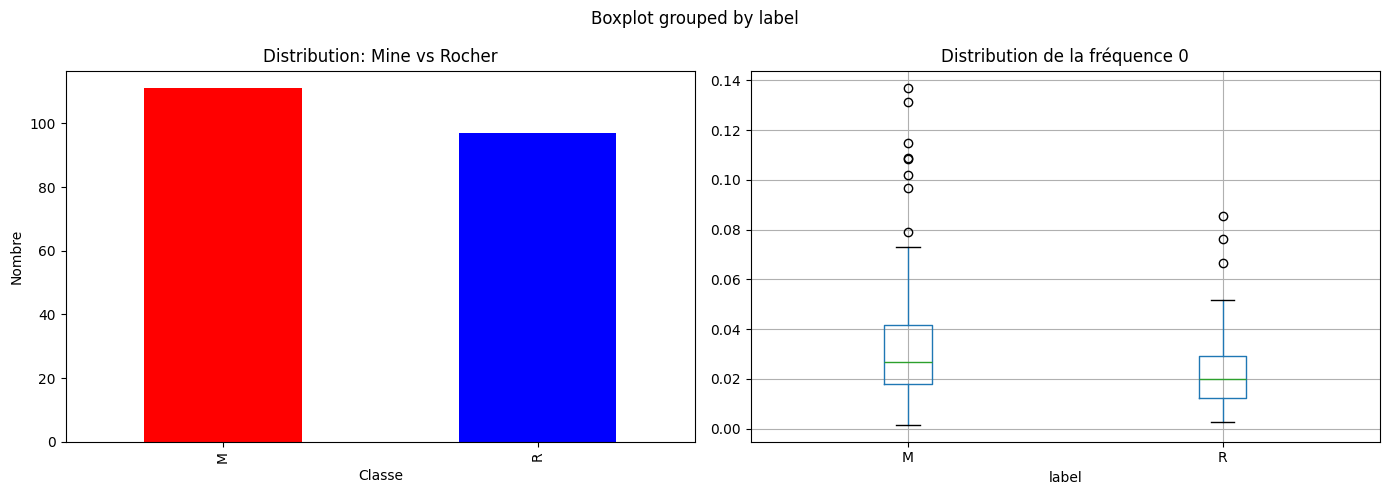

In [29]:
# Etape 4: Analyse exploratoire
import matplotlib.pyplot as plt
import seaborn as sns

# Moyenne des features par classe
moyenne_par_classe = donnees_sonar.groupby('label')[colonnes[:60]].mean()

print("Moyenne des 5 premières features par classe:")
print(moyenne_par_classe.iloc[:, :5])

# Visualisation des distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme des labels
donnees_sonar['label'].value_counts().plot(kind='bar', ax=axes[0], color=['red', 'blue'])
axes[0].set_title('Distribution: Mine vs Rocher')
axes[0].set_ylabel('Nombre')
axes[0].set_xlabel('Classe')

# Boxplot de la première feature
donnees_sonar.boxplot(column='freq_0', by='label', ax=axes[1])
axes[1].set_title('Distribution de la fréquence 0')

plt.tight_layout()
plt.show()

In [30]:
# Etape 5: Corrélation avec le label
import numpy as np

# Convertir les labels en nombres (M=1, R=0)
donnees_sonar['label_numeric'] = (donnees_sonar['label'] == 'M').astype(int)

# Calculer la corrélation avec le label
correlations = donnees_sonar[colonnes[:60] + ['label_numeric']].corr()['label_numeric'][:-1].sort_values(ascending=False)

print("Top 10 features les plus corrélées:")
print(correlations.head(10))

print("\nTop 10 features les moins corrélées:")
print(correlations.tail(10))

Top 10 features les plus corrélées:
freq_10    0.432855
freq_11    0.392245
freq_48    0.351312
freq_9     0.341142
freq_44    0.339406
freq_47    0.329333
freq_8     0.321448
freq_12    0.312811
freq_45    0.305610
freq_46    0.301697
Name: label_numeric, dtype: float64

Top 10 features les moins corrélées:
freq_16   -0.003969
freq_39   -0.035928
freq_37   -0.040527
freq_31   -0.055275
freq_32   -0.107184
freq_30   -0.110728
freq_33   -0.172010
freq_36   -0.209055
freq_34   -0.227670
freq_35   -0.269151
Name: label_numeric, dtype: float64


In [32]:
# Etape 6: Préparation du dataset pour le Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Séparation des features et du label
X = donnees_sonar.iloc[:, :60].values  # 60 features
y = donnees_sonar['label_numeric'].values  # 0 ou 1

# Normalisation des features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Division train/test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"Ensemble d'entraînement: {X_train.shape}")
print(f"Ensemble de test: {X_test.shape}")
print(f"Proportion Mine en train: {y_train.sum()/len(y_train):.2%}")
print(f"Proportion Mine en test: {y_test.sum()/len(y_test):.2%}")

Ensemble d'entraînement: (166, 60)
Ensemble de test: (42, 60)
Proportion Mine en train: 53.61%
Proportion Mine en test: 52.38%


In [33]:
# Etape 7: Régression Linéaire
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Entraînement
model_lr = LogisticRegression(random_state=42, max_iter=1000)
model_lr.fit(X_train, y_train)

# Prédictions
y_pred = model_lr.predict(X_test)

# Évaluation
print("=== Régression Logistique ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
print(f"\nMatrice de confusion:\n{confusion_matrix(y_test, y_pred)}")

=== Régression Logistique ===
Accuracy: 0.8095
Precision: 0.8182
Recall: 0.8182
F1-Score: 0.8182

Matrice de confusion:
[[16  4]
 [ 4 18]]


In [18]:
# Etape 8: Arbre de Décision
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Entraînement
model_tree = DecisionTreeClassifier(random_state=42, max_depth=10)
model_tree.fit(X_train, y_train)

# Prédictions
y_pred_tree = model_tree.predict(X_test)

# Évaluation
print("=== Arbre de Décision ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_tree):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_tree):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_tree):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_tree):.4f}")
print(f"\nMatrice de confusion:\n{confusion_matrix(y_test, y_pred_tree)}")

=== Arbre de Décision ===
Accuracy: 0.8333
Precision: 0.7778
Recall: 0.9545
F1-Score: 0.8571

Matrice de confusion:
[[14  6]
 [ 1 21]]


In [34]:
# Etape 9: Forêt Aléatoire (Random Forest)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Entraînement
model_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model_rf.fit(X_train, y_train)

# Prédictions
y_pred_rf = model_rf.predict(X_test)

# Évaluation
print("=== Forêt Aléatoire ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf):.4f}")
print(f"\nMatrice de confusion:\n{confusion_matrix(y_test, y_pred_rf)}")

# Importance des features
importances = model_rf.feature_importances_
top_features = np.argsort(importances)[-10:]
print(f"\nTop 10 features les plus importantes:")
for idx in top_features[::-1]:
    print(f"  freq_{idx}: {importances[idx]:.4f}")

=== Forêt Aléatoire ===
Accuracy: 0.8095
Precision: 0.7917
Recall: 0.8636
F1-Score: 0.8261

Matrice de confusion:
[[15  5]
 [ 3 19]]

Top 10 features les plus importantes:
  freq_10: 0.0665
  freq_8: 0.0537
  freq_11: 0.0459
  freq_47: 0.0402
  freq_9: 0.0387
  freq_48: 0.0355
  freq_12: 0.0331
  freq_4: 0.0235
  freq_15: 0.0222
  freq_46: 0.0220


In [35]:
# Etape 10: Comparaison des modèles
import pandas as pd

# Résumé des performances
results = {
    'Modèle': ['Régression Logistique', 'Arbre de Décision', 'Forêt Aléatoire'],
    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Precision': [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_tree),
        precision_score(y_test, y_pred_rf)
    ],
    'Recall': [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_tree),
        recall_score(y_test, y_pred_rf)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_tree),
        f1_score(y_test, y_pred_rf)
    ]
}

results_df = pd.DataFrame(results)
print("=== COMPARAISON DES MODÈLES ===")
print(results_df.to_string(index=False))

=== COMPARAISON DES MODÈLES ===
               Modèle  Accuracy  Precision   Recall  F1-Score
Régression Logistique  0.809524   0.818182 0.818182  0.818182
    Arbre de Décision  0.833333   0.777778 0.954545  0.857143
      Forêt Aléatoire  0.809524   0.791667 0.863636  0.826087


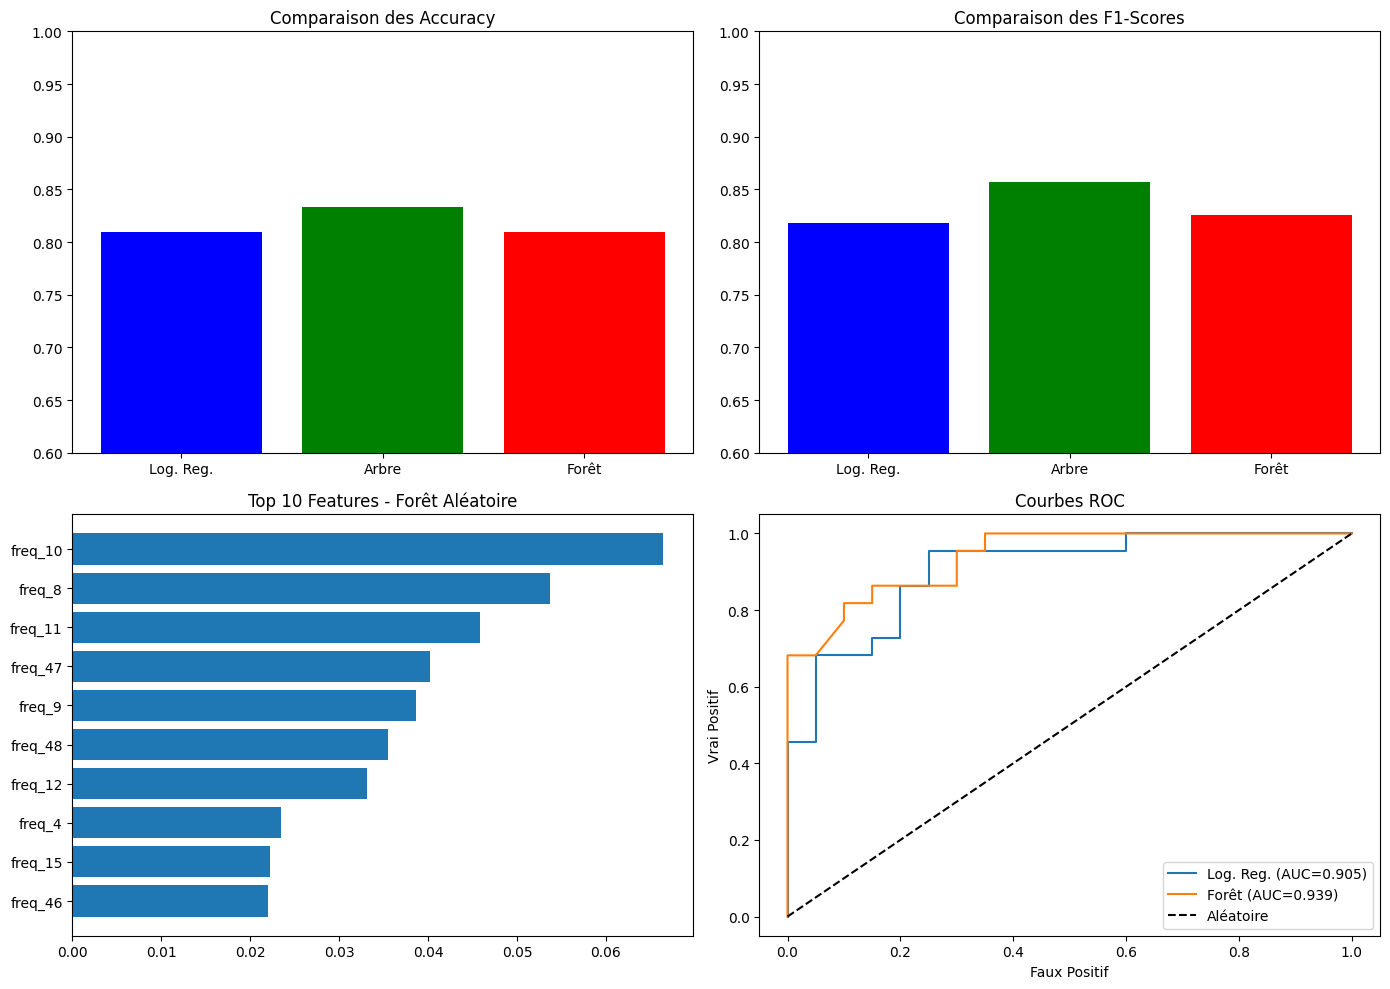

In [36]:
# Etape 11: Visualisation des résultats
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Comparaison Accuracy
models = ['Log. Reg.', 'Arbre', 'Forêt']
accuracies = [
    accuracy_score(y_test, y_pred),
    accuracy_score(y_test, y_pred_tree),
    accuracy_score(y_test, y_pred_rf)
]
axes[0, 0].bar(models, accuracies, color=['blue', 'green', 'red'])
axes[0, 0].set_title('Comparaison des Accuracy')
axes[0, 0].set_ylim([0.6, 1.0])

# 2. Comparaison F1-Score
f1_scores = [
    f1_score(y_test, y_pred),
    f1_score(y_test, y_pred_tree),
    f1_score(y_test, y_pred_rf)
]
axes[0, 1].bar(models, f1_scores, color=['blue', 'green', 'red'])
axes[0, 1].set_title('Comparaison des F1-Scores')
axes[0, 1].set_ylim([0.6, 1.0])

# 3. Importance des features (Forêt Aléatoire)
top_10_idx = np.argsort(importances)[-10:]
axes[1, 0].barh([f'freq_{i}' for i in top_10_idx], importances[top_10_idx])
axes[1, 0].set_title('Top 10 Features - Forêt Aléatoire')

# 4. Courbes ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, model_lr.predict_proba(X_test)[:, 1])
fpr_rf, tpr_rf, _ = roc_curve(y_test, model_rf.predict_proba(X_test)[:, 1])

auc_lr = auc(fpr_lr, tpr_lr)
auc_rf = auc(fpr_rf, tpr_rf)

axes[1, 1].plot(fpr_lr, tpr_lr, label=f'Log. Reg. (AUC={auc_lr:.3f})')
axes[1, 1].plot(fpr_rf, tpr_rf, label=f'Forêt (AUC={auc_rf:.3f})')
axes[1, 1].plot([0, 1], [0, 1], 'k--', label='Aléatoire')
axes[1, 1].set_xlabel('Faux Positif')
axes[1, 1].set_ylabel('Vrai Positif')
axes[1, 1].set_title('Courbes ROC')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [37]:
# Etape 12: Sauvegarde du meilleur modèle
import joblib
import os

# Créer le dossier s'il n'existe pas
os.makedirs('modeles', exist_ok=True)

# Le meilleur modèle est la Forêt Aléatoire
joblib.dump(model_rf, 'modeles/sonar_model.pkl')
joblib.dump(scaler, 'modeles/sonar_scaler.pkl')

print("✓ Modèle Forêt Aléatoire sauvegardé dans 'modeles/sonar_model.pkl'")
print("✓ Scaler sauvegardé dans 'modeles/sonar_scaler.pkl'")

✓ Modèle Forêt Aléatoire sauvegardé dans 'modeles/sonar_model.pkl'
✓ Scaler sauvegardé dans 'modeles/sonar_scaler.pkl'


In [23]:
# Import sckit learn
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

X_APPRENTISSAGE, X_VALIDATION, Y_APPRENTISSAGE, Y_VALIDATION = train_test_split(X, y, test_size=0.2, random_state= 0) 

algorithme = LinearRegression()

algorithme.fit(X_APPRENTISSAGE, Y_APPRENTISSAGE)

predictions = algorithme.predict(X_VALIDATION)

precisions = r2_score(Y_VALIDATION, predictions)
print(predictions)
print(precisions)    

[ 2.35873153e-01  5.83602066e-01  6.70723641e-01  4.27850185e-01
  1.14321700e+00  5.08841934e-01  7.25601709e-01  1.12587611e+00
 -2.04072226e-01  3.63449444e-01  5.93001985e-01  8.14124991e-01
  4.29724296e-01  5.52373615e-01  7.44031298e-02  1.60143102e-01
  9.25765723e-01  1.19449661e-01 -1.43218098e-01 -1.96415873e-01
  7.80808784e-01 -8.36990817e-04  7.16617151e-01  2.54358760e-01
  1.11949236e-01  2.98452239e-01  5.87694555e-01  8.45621018e-01
  7.05876708e-01  1.29829583e+00  1.37712989e-01  8.54997652e-01
  6.92120612e-01  2.55277042e-01  1.08166160e+00  6.04048362e-01
  9.73201271e-01  5.97774855e-01  1.00153658e-01  6.08720781e-01
  5.72548405e-01  2.29201011e-01]
0.5092925464500369


In [24]:
# Import sckit learn
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

#X_APPRENTISSAGE, X_VALIDATION, Y_APPRENTISSAGE, Y_VALIDATION = train_test_split(X, y, test_size=0.2, random_state= 0) 

algorithme = DecisionTreeRegressor()

algorithme.fit(X_APPRENTISSAGE, Y_APPRENTISSAGE)

predictions = algorithme.predict(X_VALIDATION)

precisions = r2_score(Y_VALIDATION, predictions)
print(predictions)
print(precisions)    

[0. 1. 1. 0. 1. 1. 1. 1. 1. 0. 1. 1. 0. 1. 0. 0. 1. 0. 0. 0. 1. 0. 1. 1.
 0. 1. 0. 1. 1. 1. 0. 0. 1. 0. 1. 1. 1. 1. 1. 1. 1. 0.]
-0.04761904761904767


In [25]:
# Import sckit learn
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

#X_APPRENTISSAGE, X_VALIDATION, Y_APPRENTISSAGE, Y_VALIDATION = train_test_split(X, y, test_size=0.2, random_state= 0) 

algorithme = RandomForestRegressor()

algorithme.fit(X_APPRENTISSAGE, Y_APPRENTISSAGE)

predictions = algorithme.predict(X_VALIDATION)
precisions_apprentissage = algorithme.score(X_APPRENTISSAGE, Y_APPRENTISSAGE)
precisions = r2_score(Y_VALIDATION, predictions)
print(predictions)
print(precisions) 

[0.28 0.64 0.59 0.55 0.92 0.26 0.86 0.61 0.29 0.39 0.43 0.91 0.1  0.98
 0.18 0.33 0.79 0.02 0.08 0.11 0.61 0.4  0.77 0.41 0.36 0.63 0.8  0.71
 0.88 0.91 0.28 0.61 0.63 0.1  0.87 0.91 0.71 0.86 0.72 0.53 0.86 0.38]
0.5101142857142857


In [26]:
# Etape 13: Prédiction sur un nouvel exemple
# Test avec quelques exemples du test set
print("=== PRÉDICTIONS SUR NOUVEAUX EXEMPLES ===\n")

for i in range(5):
    echantillon = X_test[i].reshape(1, -1)
    label_reel = 'Mine' if y_test[i] == 1 else 'Rocher'
    
    pred_rf = 'Mine' if model_rf.predict(echantillon)[0] == 1 else 'Rocher'
    confidence = max(model_rf.predict_proba(echantillon)[0])
    
    print(f"Exemple {i+1}:")
    print(f"  Label réel: {label_reel}")
    print(f"  Prédiction: {pred_rf} (confiance: {confidence:.2%})")
    print()

=== PRÉDICTIONS SUR NOUVEAUX EXEMPLES ===

Exemple 1:
  Label réel: Mine
  Prédiction: Rocher (confiance: 52.00%)

Exemple 2:
  Label réel: Mine
  Prédiction: Mine (confiance: 58.00%)

Exemple 3:
  Label réel: Mine
  Prédiction: Mine (confiance: 71.00%)

Exemple 4:
  Label réel: Mine
  Prédiction: Mine (confiance: 92.00%)

Exemple 5:
  Label réel: Rocher
  Prédiction: Rocher (confiance: 70.00%)

